# ___

# [ Machine Learning in Geosciences ]

**Department of Applied Geoinformatics and Carthography, Charles University** 

*Lukas Brodsky lukas.brodsky@natur.cuni.cz*



## Classifer model generalization exercises

Tasks: 

1. Test if the problem (given the dataset) is linearly separabile, compare Logistic Regresion and Decision Trees.  

2. Evaluate when the Decision Tree starts overfitting with regard to the tree depth.  

3. Tune DT hyperparameters using cross-validation with grid search technique. Report the best hyperparameters and achieved accuracy. 

In [14]:
import numpy as np
np.random.seed(0)
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Sample data

In [5]:
X, y = make_classification(n_samples=10000, n_features=20,
                           n_informative=5, n_redundant=15, random_state=1)

In [7]:
X.shape

(10000, 20)

In [6]:
# Classes
np.unique(y)

array([0, 1])

In [9]:
# Split traina nd test (50%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [10]:
X_train.shape

(5000, 20)

### 1. Is the problem linearly separable? 
Test logistic regression model. 

In [27]:
# instantiate Logistic regression model
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model

DecisionTreeClassifier(max_depth=10, random_state=42)

In [28]:
# fit model
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [29]:
y_train_pred = model.predict(X_train)
y_train_pred

array([0, 0, 0, ..., 0, 0, 1])

In [30]:
# train accuracy
train_OA = accuracy_score(y_train, y_train_pred)
print(f'Training Accuracy: {train_OA * 100.} %') 

Training Accuracy: 96.7 %


In [31]:
# test accuracy
y_test_pred = model.predict(X_test)
y_test_pred
test_OA = accuracy_score(y_test, y_test_pred)
print(f'Testing Accuracy: {test_OA * 100.} %') 

Testing Accuracy: 91.60000000000001 %


In [ ]:
# Evalaute the model

### Compare it with Decision Tree Classifier

In [ ]:
# DT model
pass 

In [ ]:
# fit 
pass

In [ ]:
# train accuracy
pass 

In [ ]:
# test accuracy
pass 

### 2. When the DT() model starts overfitting with regard to the depth of the tree? 

In [46]:
# Run set of training procedures and evaluation while changing the dtree depth from 1 to 10 
# Store the training and testing accuracy 

train_acc = [] 
test_acc = [] 

for d in range(1, 21, 1): 
    print(d)
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    # training acc. 
    y_train_pred = model.predict(X_train)
    train_OA = accuracy_score(y_train, y_train_pred)
    print(f'Training Accuracy: {train_OA * 100.} %') 
    # testing acc. 
    train_acc.append(train_OA * 100.)
    y_test_pred = model.predict(X_test)
    test_OA = accuracy_score(y_test, y_test_pred)
    print(f'Testing Accuracy: {test_OA * 100.} %') 
    test_acc.append(test_OA * 100.) 
    print('---')  

1
Training Accuracy: 76.88000000000001 %
Testing Accuracy: 76.44 %
---
2
Training Accuracy: 80.38 %
Testing Accuracy: 80.9 %
---
3
Training Accuracy: 88.08 %
Testing Accuracy: 87.94 %
---
4
Training Accuracy: 90.06 %
Testing Accuracy: 89.64 %
---
5
Training Accuracy: 91.24 %
Testing Accuracy: 90.25999999999999 %
---
6
Training Accuracy: 93.22 %
Testing Accuracy: 91.47999999999999 %
---
7
Training Accuracy: 94.02000000000001 %
Testing Accuracy: 91.72 %
---
8
Training Accuracy: 94.86 %
Testing Accuracy: 91.58 %
---
9
Training Accuracy: 95.62 %
Testing Accuracy: 91.78 %
---
10
Training Accuracy: 96.7 %
Testing Accuracy: 91.60000000000001 %
---
11
Training Accuracy: 97.6 %
Testing Accuracy: 91.82000000000001 %
---
12
Training Accuracy: 98.26 %
Testing Accuracy: 91.8 %
---
13
Training Accuracy: 98.66 %
Testing Accuracy: 91.42 %
---
14
Training Accuracy: 98.83999999999999 %
Testing Accuracy: 91.28 %
---
15
Training Accuracy: 99.18 %
Testing Accuracy: 91.4 %
---
16
Training Accuracy: 99.46000

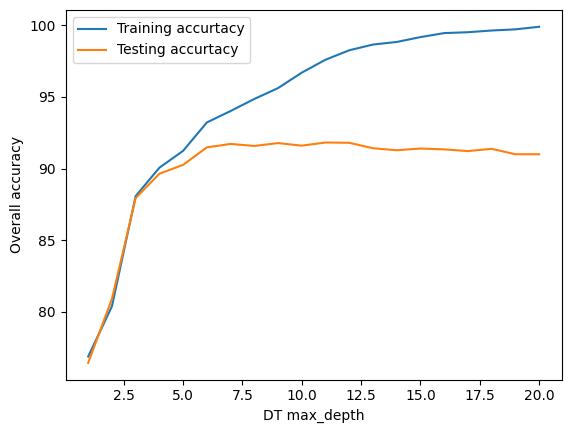

In [47]:
# Plot dependence of the model training and testing accuracy against the depth of the model.
plt.plot(list(range(1, 21, 1)), train_acc, label='Training accurtacy')
plt.plot(list(range(1, 21, 1)), test_acc, label='Testing accurtacy')
plt.xlabel('DT max_depth')
plt.ylabel('Overall accuracy')
plt.legend()

In [50]:
(train_acc[4] - test_acc[4]) 

0.980000000000004

In [ ]:
# When the model starts overfitting? 

### 3. Finetune the DT model through cross-validation and grid search, report accuracy. 

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
# instantiate the model
pass 

In [ ]:
# Apply grid search of hyperparameters and cross-validation 
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
hyperparameter_space = {'max_depth': [2,4,6,8,10,15,20,50,100],
                        'min_samples_leaf': [1,2,4,6,8,10,20,30]}

gs = GridSearchCV(model, param_grid=hyperparameter_space, n_jobs=2,
                  scoring="accuracy", cv=5, return_train_score=True)

# run fit (be aware: takes longer!)
gs.fit(X_train, y_train)

In [ ]:
# Optimal parameters and scores 
print("Optimal hyperparameter combination: ", gs.best_params_)
print("Mean cross-validated accuracy of the best_estimator: ", round(gs.best_score_ * 100, 2))

In [ ]:
# Test accuracy
pass


In [ ]:
# Evaluate the result 